# 03 - Customer Clustering

Customer segmentation with KMeans and churn profile per cluster.


In [1]:
from pathlib import Path
from IPython.display import display
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

TRAIN_TEST_DIR = Path('../data/train_test')
REPORTS_DIR = Path('../reports')
MODEL_DIR = Path('../models')
print('Environment ready')


Environment ready


In [2]:
X_train = pd.read_csv(TRAIN_TEST_DIR / 'X_train_processed.csv')
y_train = pd.read_csv(TRAIN_TEST_DIR / 'y_train.csv').squeeze('columns')
print('X_train shape:', X_train.shape)
print('Target distribution in training set')
display(y_train.value_counts(normalize=True).rename('rate').to_frame())


X_train shape: (3497, 134)
Target distribution in training set


,rate
Churn,
0,0.667429
1,0.332571


In [3]:
k_results = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_train)
    k_results.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(X_train, labels),
    })
k_results = pd.DataFrame(k_results)
print('KMeans comparison')
display(k_results.round(4))


KMeans comparison


,k,inertia,silhouette
0,2,140372.6129,0.9138
1,3,127147.8154,0.7950
2,4,116312.8644,0.1076
3,5,109801.0719,0.0938
4,6,105543.3090,0.0878
5,7,101746.3532,0.0932
6,8,98004.0062,0.0948


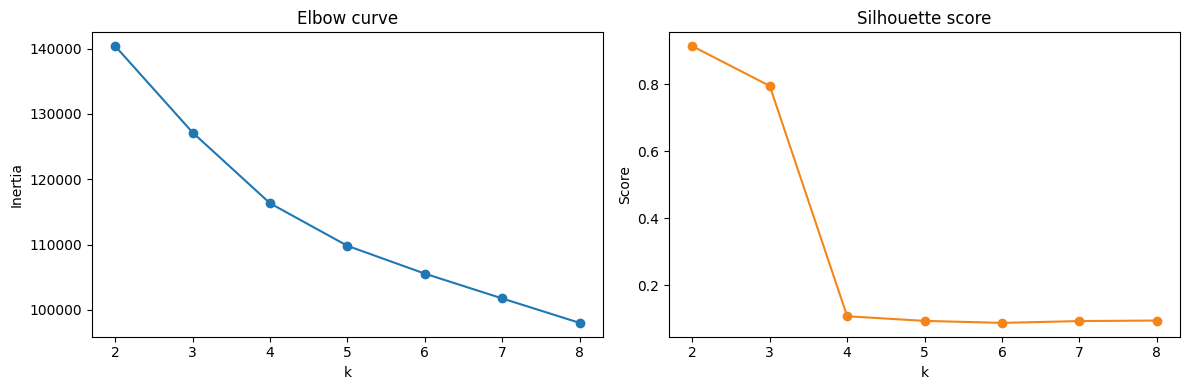

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_results['k'], k_results['inertia'], marker='o')
axes[0].set_title('Elbow curve')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot(k_results['k'], k_results['silhouette'], marker='o', color='#f58518')
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()


In [5]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train)
silhouette = silhouette_score(X_train, clusters)
print('Selected model: KMeans with k=3')
print('Silhouette score:', round(silhouette, 4))


Selected model: KMeans with k=3
Silhouette score: 0.795


In [6]:
cluster_df = pd.DataFrame({'Cluster': clusters, 'Churn': y_train})
cluster_summary = cluster_df.groupby('Cluster').agg(
    Number_of_Customers=('Cluster', 'count'),
    Churn_Rate=('Churn', 'mean'),
)
cluster_summary['Churn_Rate'] = (cluster_summary['Churn_Rate'] * 100).round(2)
cluster_summary['Share_Percent'] = (cluster_summary['Number_of_Customers'] / len(cluster_df) * 100).round(2)
print('Cluster summary')
display(cluster_summary)


Cluster summary


,Number_of_Customers,Churn_Rate,Share_Percent
Cluster,,,
0,3480,33.39,99.51
1,15,0.00,0.43
2,2,50.00,0.06


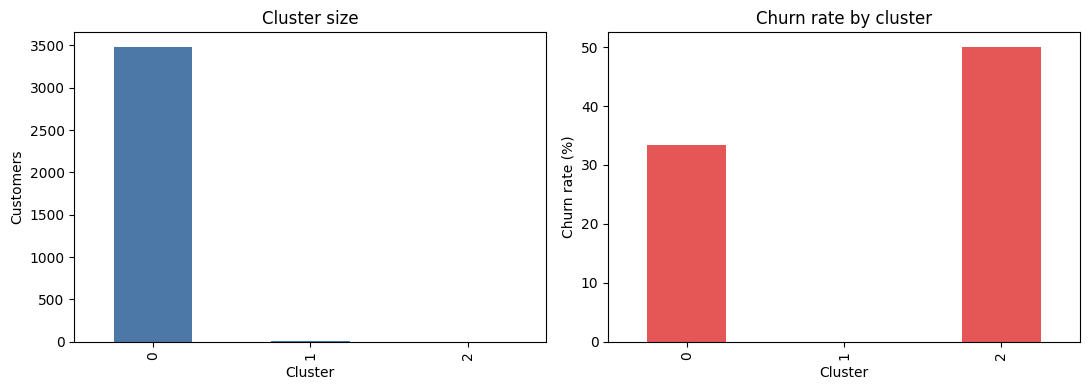

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cluster_summary['Number_of_Customers'].plot(kind='bar', ax=axes[0], color='#4c78a8')
axes[0].set_title('Cluster size')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Customers')
cluster_summary['Churn_Rate'].plot(kind='bar', ax=axes[1], color='#e45756')
axes[1].set_title('Churn rate by cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Churn rate (%)')
plt.tight_layout()
plt.show()


In [8]:
cluster_profiles = pd.DataFrame(X_train).assign(Cluster=clusters).groupby('Cluster').mean().iloc[:, :12].round(3)
print('Cluster profile on first processed features')
display(cluster_profiles)


Cluster profile on first processed features


C:\Users\USER\AppData\Local\Temp\ipykernel_39808\3023899987.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cluster_profiles = pd.DataFrame(X_train).assign(Cluster=clusters).groupby('Cluster').mean().iloc[:, :12].round(3)


,0,1,2,3,4,5,6,7,8,9,10,11
Cluster,,,,,,,,,,,,
0,0.003,-0.040,-0.046,-0.003,-0.024,0.023,-0.024,-0.048,-0.001,0.024,-0.025,-0.007
1,-0.873,9.245,10.663,0.615,0.019,-0.287,0.408,11.096,0.308,-0.059,0.327,1.593
2,0.711,-0.269,-0.250,-0.216,41.001,-38.171,38.098,-0.293,-0.193,-41.531,41.490,-0.240


In [9]:
saved_cluster_summary = pd.read_csv(REPORTS_DIR / 'cluster_summary.csv')
print('Saved report from reports/cluster_summary.csv')
display(saved_cluster_summary)


Saved report from reports/cluster_summary.csv


,Cluster,Number_of_Customers,Churn_Rate
0,0,3480,33.390805
1,1,15,0.000000
2,2,2,50.000000


In [10]:
saved_model = joblib.load(MODEL_DIR / 'kmeans_customer_segments.joblib')
print('Saved model type:', type(saved_model).__name__)
print('Saved model clusters:', saved_model.n_clusters)


Saved model type: KMeans
Saved model clusters: 3


## Clustering conclusion

The cluster summary identifies customer groups with different churn exposure. These segments can guide retention campaigns.
